In [33]:
%pip install playwright beautifulsoup4 numpy pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
!playwright install chromium

(node:25201) [DEP0169] DeprecationWarning: `url.parse()` behavior is not standardized and prone to errors that have security implications. Use the WHATWG URL API instead. CVEs are not issued for `url.parse()` vulnerabilities.
(Use `node --trace-deprecation ...` to show where the warning was created)
162.3 MiB [                    ] 0% 0.0s162.3 MiB [                    ] 0% 484.0s162.3 MiB [                    ] 0% 306.4s162.3 MiB [                    ] 0% 308.8s162.3 MiB [                    ] 0% 478.5s162.3 MiB [                    ] 0% 400.4s162.3 MiB [                    ] 0% 542.6s162.3 MiB [                    ] 0% 461.0s162.3 MiB [                    ] 0% 404.4s162.3 MiB [                    ] 0% 385.5s162.3 MiB [                    ] 0% 351.4s162.3 MiB [                    ] 0% 334.0s162.3 MiB [                    ] 0% 328.7s162.3 MiB [                    ] 0% 311.4s162.3 MiB [                    ] 0% 301.0s162.3 MiB [                    ] 0% 287.1s162.3 MiB [                  

In [ ]:
from playwright.async_api import async_playwright
import asyncio

async def scrape():
    async with async_playwright() as p:
        # Запускаем браузер
        browser = await p.chromium.launch(headless=False)
        
        # Создаем контекст с user-agent и размером окна
        context = await browser.new_context(
            user_agent='Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
            viewport={'width': 1920, 'height': 1080}
        )
        
        page = await context.new_page()
        
        # Переходим на страницу
        await page.goto('https://realty.yandex.ru/moskva/kupit/novostrojka/', wait_until='domcontentloaded')
        
        print('Страница загружена, ждем...')
        await asyncio.sleep(3)
        
        # Прокручиваем страницу
        for i in range(50):
            await page.evaluate('window.scrollBy(0, window.innerHeight)')
            print(f'Прокрутка {i+1}/50 выполнена')
            await asyncio.sleep(2)
        
        html = await page.content()

        await browser.close()
        
        return html
    
html = await scrape()
with open('yandex_realty.html', 'w', encoding='utf-8') as f:
    f.write(html)

Страница загружена, ждем...
Прокрутка 1/50 выполнена
Прокрутка 2/50 выполнена
Прокрутка 3/50 выполнена
Прокрутка 4/50 выполнена
Прокрутка 5/50 выполнена
Прокрутка 6/50 выполнена
Прокрутка 7/50 выполнена
Прокрутка 8/50 выполнена
Прокрутка 9/50 выполнена
Прокрутка 10/50 выполнена
Прокрутка 11/50 выполнена
Прокрутка 12/50 выполнена
Прокрутка 13/50 выполнена
Прокрутка 14/50 выполнена
Прокрутка 15/50 выполнена
Прокрутка 16/50 выполнена
Прокрутка 17/50 выполнена
Прокрутка 18/50 выполнена
Прокрутка 19/50 выполнена
Прокрутка 20/50 выполнена
Прокрутка 21/50 выполнена
Прокрутка 22/50 выполнена
Прокрутка 23/50 выполнена
Прокрутка 24/50 выполнена
Прокрутка 25/50 выполнена
Прокрутка 26/50 выполнена
Прокрутка 27/50 выполнена
Прокрутка 28/50 выполнена
Прокрутка 29/50 выполнена
Прокрутка 30/50 выполнена
Прокрутка 31/50 выполнена
Прокрутка 32/50 выполнена
Прокрутка 33/50 выполнена
Прокрутка 34/50 выполнена
Прокрутка 35/50 выполнена
Прокрутка 36/50 выполнена
Прокрутка 37/50 выполнена
Прокрутка 38/50 вып

In [139]:
from bs4 import BeautifulSoup
import pandas as pd

# Загружаем HTML файл
with open('yandex_realty.html', 'r', encoding='utf-8') as f:
    html = f.read()

# Парсим HTML
soup = BeautifulSoup(html, 'html.parser')

# Ищем все элементы с классом, содержащим "snippet"
snippets = soup.select('[data-seo="snippet"]')
print(f'Найдено элементов с [data-seo="snippet"]: {len(snippets)}')


Найдено элементов с [data-seo="snippet"]: 240


In [140]:
# Собираем данные из каждой карточки
import re
from pprint import pprint

def parse_price_table_row(price_row):
    area = price_row.find(class_=lambda x: x and 'SnippetPriceTable__area' in x)
    area_text = area.get_text(strip=True) if area else ''
    area_match = re.search(r'\b(\d+(?:,\d+)?)\b', area_text)
    price = price_row.find(class_=lambda x: x and 'SnippetPriceTable__price' in x)
    price_text = price.get_text(strip=True) if price else ''
    price_match = re.search(r'\b(\d+(?:,\d+)?)\b', price_text)
    return float(area_match.group(1).replace(',', '.')) if area_match else None, float(price_match.group(1).replace(',', '.')) if price_match else None

def parse_snippets(snippets):
    data = []

    for snippet in snippets:
        item = {}
    
        # Название ЖК (ссылка)
        link = snippet.find('a', attrs={'data-test': 'SiteSnippetSearchHeadingLink'})
        if link:
            item['title'] = link.get_text(strip=True)
            href = link.get('href', '')
            if href and not href.startswith('http'):
                href = 'https://realty.yandex.ru' + href
            item['link'] = href
    
        # Метро
        metro = snippet.find(attrs={'data-test': 'MetroWithTime'})
        if metro:
            metro_text = metro.get_text()
            match = re.match(r'^(.+?)\s+(\d+)\sмин', metro_text)
            if match:
                item['metro_station'] = match.group(1)
                item['metro_time_min'] = int(match.group(2))
            else:
                item['metro_station'] = metro_text
                item['metro_time_min'] = None

        # Метраж и цена
        price_rows = snippet.find_all(class_=lambda x: x and 'SnippetPriceTable__row' in x)
        if price_rows:
            price_row_min = price_rows[0]
            area_min, price_min = parse_price_table_row(price_row_min)
            item['area_min'] = area_min
            item['price_min'] = price_min
            price_row_max = price_rows[-1]
            area_max, price_max = parse_price_table_row(price_row_max)
            item['area_max'] = area_max
            item['price_max'] = price_max

        # Добавляем только если есть хоть какие-то данные
        if len(item) > 0:
            data.append(item)
    return data

data = parse_snippets(snippets)

pprint(data[:5])


[{'area_max': 107.1,
  'area_min': 25.3,
  'link': 'https://realty.yandex.ru/moskva_i_moskovskaya_oblast/kupit/novostrojka/cityzen-3850850/',
  'metro_station': 'Тушинская',
  'metro_time_min': 10,
  'price_max': 44.0,
  'price_min': 16.1,
  'title': 'CITYZEN'},
 {'area_max': 95.3,
  'area_min': 26.0,
  'link': 'https://realty.yandex.ru/moskva_i_moskovskaya_oblast/kupit/novostrojka/city-bay-2287072/',
  'metro_station': 'Трикотажная',
  'metro_time_min': 7,
  'price_max': 33.1,
  'price_min': 15.8,
  'title': 'City Bay'},
 {'area_max': 97.4,
  'area_min': 22.9,
  'link': 'https://realty.yandex.ru/moskva_i_moskovskaya_oblast/kupit/novostrojka/set-4014763/',
  'metro_station': 'Давыдково',
  'metro_time_min': 20,
  'price_max': 46.8,
  'price_min': 17.4,
  'title': 'СЕТ'},
 {'area_max': 142.9,
  'area_min': 40.6,
  'link': 'https://realty.yandex.ru/moskva_i_moskovskaya_oblast/kupit/novostrojka/klubnyj-gorod-na-reke-primavera-2804626/',
  'metro_station': 'Спартак',
  'metro_time_min': 12

In [141]:
# Создаем DataFrame
df = pd.DataFrame(data)
print(f'Собрано записей: {len(df)}')
if len(df) > 0:
    print(f'Столбцы: {df.columns.tolist()}')
    display(df.head())
else:
    print('Данные не найдены')

Собрано записей: 240
Столбцы: ['title', 'link', 'metro_station', 'metro_time_min', 'area_min', 'price_min', 'area_max', 'price_max']


,title,link,metro_station,metro_time_min,area_min,price_min,area_max,price_max
0,CITYZEN,https://realty.yandex.ru/moskva_i_moskovskaya_...,Тушинская,10.0,25.3,16.1,107.1,44.0
1,City Bay,https://realty.yandex.ru/moskva_i_moskovskaya_...,Трикотажная,7.0,26.0,15.8,95.3,33.1
2,СЕТ,https://realty.yandex.ru/moskva_i_moskovskaya_...,Давыдково,20.0,22.9,17.4,97.4,46.8
3,Клубный город на реке Primavera,https://realty.yandex.ru/moskva_i_moskovskaya_...,Спартак,12.0,40.6,28.8,142.9,117.8
4,Slava,https://realty.yandex.ru/moskva_i_moskovskaya_...,Белорусская,10.0,28.1,30.2,115.1,105.6


In [142]:
display(df.describe())

print(f"\nВремя до метро:")
print(f"  Среднее: {df['metro_time_min'].mean():.1f} мин")
print(f"  Медиана: {df['metro_time_min'].median():.1f} мин")
print(f"  Мин/Макс: {df['metro_time_min'].min():.0f} / {df['metro_time_min'].max():.0f} мин")

print(f"\nПлощадь квартир (минимальная):")
print(f"  Средняя: {df['area_min'].mean():.1f} м²")
print(f"  Медиана: {df['area_min'].median():.1f} м²")
print(f"  Мин/Макс: {df['area_min'].min():.1f} / {df['area_min'].max():.1f} м²")

print(f"\nЦена (минимальная):")
print(f"  Средняя: {df['price_min'].mean():.1f} млн руб")
print(f"  Медиана: {df['price_min'].median():.1f} млн руб")
print(f"  Мин/Макс: {df['price_min'].min():.1f} / {df['price_min'].max():.1f} млн руб")

,metro_time_min,area_min,price_min,area_max,price_max
count,239.000000,240.000000,240.000000,240.000000,240.000000
mean,12.769874,38.739583,37.687500,105.687500,88.775417
std,6.086334,35.235897,62.023808,54.085105,125.266506
min,2.000000,14.100000,5.800000,41.200000,1.800000
25%,8.000000,22.900000,13.250000,71.375000,26.975000
50%,12.000000,28.250000,19.000000,91.800000,43.850000
75%,17.000000,40.450000,29.400000,119.025000,75.500000
max,38.000000,391.000000,467.900000,495.900000,795.000000



Время до метро:
  Среднее: 12.8 мин
  Медиана: 12.0 мин
  Мин/Макс: 2 / 38 мин

Площадь квартир (минимальная):
  Средняя: 38.7 м²
  Медиана: 28.2 м²
  Мин/Макс: 14.1 / 391.0 м²

Цена (минимальная):
  Средняя: 37.7 млн руб
  Медиана: 19.0 млн руб
  Мин/Макс: 5.8 / 467.9 млн руб


/var/folders/c8/dzcd_fh15mv32gjb6q_ff1gr0000gn/T/ipykernel_29805/2439392007.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(box_data, labels=['Мин. цена', 'Макс. цена'])


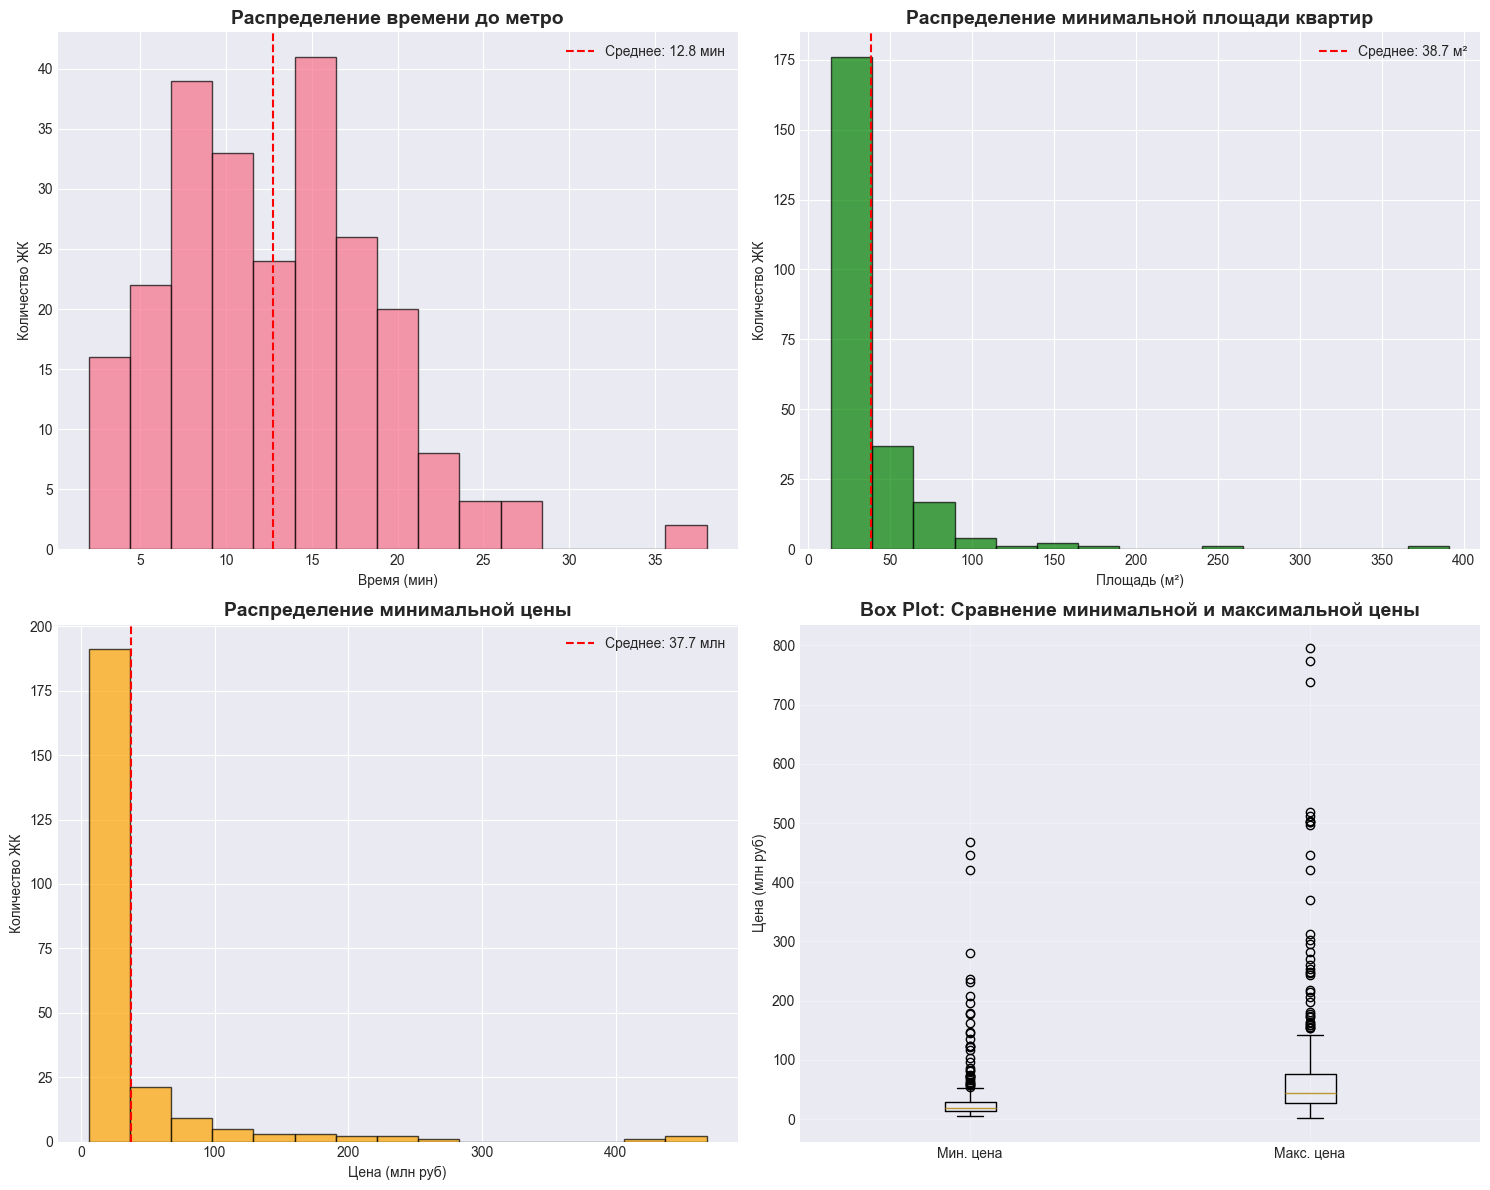

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Распределение времени до метро
axes[0, 0].hist(df['metro_time_min'].dropna(), bins=15, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Распределение времени до метро', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Время (мин)')
axes[0, 0].set_ylabel('Количество ЖК')
axes[0, 0].axvline(df['metro_time_min'].mean(), color='red', linestyle='--', label=f"Среднее: {df['metro_time_min'].mean():.1f} мин")
axes[0, 0].legend()

# 2. Распределение минимальной площади
axes[0, 1].hist(df['area_min'].dropna(), bins=15, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('Распределение минимальной площади квартир', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Площадь (м²)')
axes[0, 1].set_ylabel('Количество ЖК')
axes[0, 1].axvline(df['area_min'].mean(), color='red', linestyle='--', label=f"Среднее: {df['area_min'].mean():.1f} м²")
axes[0, 1].legend()

# 3. Распределение минимальной цены
axes[1, 0].hist(df['price_min'].dropna(), bins=15, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_title('Распределение минимальной цены', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Цена (млн руб)')
axes[1, 0].set_ylabel('Количество ЖК')
axes[1, 0].axvline(df['price_min'].mean(), color='red', linestyle='--', label=f"Среднее: {df['price_min'].mean():.1f} млн")
axes[1, 0].legend()

# 4. Box plot для цен
box_data = [df['price_min'].dropna(), df['price_max'].dropna()]
axes[1, 1].boxplot(box_data, labels=['Мин. цена', 'Макс. цена'])
axes[1, 1].set_title('Box Plot: Сравнение минимальной и максимальной цены', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Цена (млн руб)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

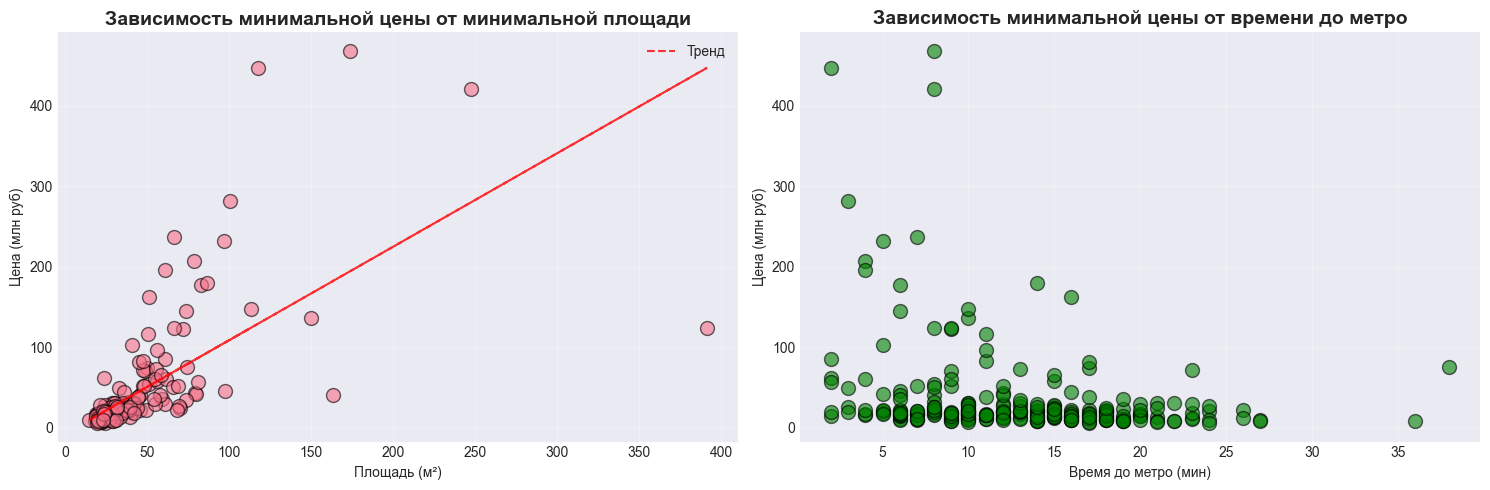

In [144]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Зависимость цены от площади
axes[0].scatter(df['area_min'], df['price_min'], alpha=0.6, s=100, edgecolors='black')
axes[0].set_title('Зависимость минимальной цены от минимальной площади', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Площадь (м²)')
axes[0].set_ylabel('Цена (млн руб)')
axes[0].grid(True, alpha=0.3)

# Добавим линию тренда
z = np.polyfit(df['area_min'].dropna(), df['price_min'].dropna(), 1)
p = np.poly1d(z)
axes[0].plot(df['area_min'], p(df['area_min']), "r--", alpha=0.8, label='Тренд')
axes[0].legend()

# 2. Зависимость цены от времени до метро
axes[1].scatter(df['metro_time_min'], df['price_min'], alpha=0.6, s=100, color='green', edgecolors='black')
axes[1].set_title('Зависимость минимальной цены от времени до метро', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Время до метро (мин)')
axes[1].set_ylabel('Цена (млн руб)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [145]:
# ТОП-5 самых дешевых ЖК
print("=" * 70)
print("ТОП-5 САМЫХ ДЕШЕВЫХ ЖК (по минимальной цене)")
print("=" * 70)
top_cheap = df.nsmallest(5, 'price_min')[['title', 'price_min', 'area_min', 'metro_station', 'metro_time_min']]
display(top_cheap)

# ТОП-5 самых дорогих ЖК
print("\n" + "=" * 70)
print("ТОП-5 САМЫХ ДОРОГИХ ЖК (по минимальной цене)")
print("=" * 70)
top_expensive = df.nlargest(5, 'price_min')[['title', 'price_min', 'area_min', 'metro_station', 'metro_time_min']]
display(top_expensive)

# ТОП-5 ЖК, ближайших к метро
print("\n" + "=" * 70)
print("ТОП-5 ЖК, БЛИЖАЙШИХ К МЕТРО")
print("=" * 70)
top_metro = df.nsmallest(5, 'metro_time_min')[['title', 'metro_station', 'metro_time_min', 'price_min', 'area_min']]
display(top_metro)

ТОП-5 САМЫХ ДЕШЕВЫХ ЖК (по минимальной цене)


,title,price_min,area_min,metro_station,metro_time_min
215,Люберцы,5.8,19.0,Некрасовка,24.0
145,Ильинойс,6.3,24.3,Красногорская,17.0
177,Большое Путилково,7.2,21.7,Волоколамская,21.0
180,Пятницкое 58,7.3,20.2,Пятницкое шоссе,10.0
158,Подольские Кварталы,7.5,21.8,Остафьево,17.0



ТОП-5 САМЫХ ДОРОГИХ ЖК (по минимальной цене)


,title,price_min,area_min,metro_station,metro_time_min
157,Левенсон,467.9,173.3,Тверская,8.0
162,Русские сезоны,446.6,117.2,Третьяковская,2.0
129,Lucky,420.2,247.1,Улица 1905 года,8.0
138,Никитский-6,281.3,100.2,Арбатская,3.0
237,Лаврушинский,236.2,66.4,Полянка,7.0



ТОП-5 ЖК, БЛИЖАЙШИХ К МЕТРО


,title,metro_station,metro_time_min,price_min,area_min
43,НАЗАРÉ,Бульвар Рокоссовского,2.0,14.8,21.4
50,INDY TOWERS,Зорге,2.0,19.0,21.2
90,Энигмия,Менделеевская,2.0,85.8,60.6
162,Русские сезоны,Третьяковская,2.0,446.6,117.2
208,Vesper Tverskaya,Маяковская,2.0,62.0,23.4


СТАТИСТИКА ПО ЦЕНЕ ЗА КВАДРАТНЫЙ МЕТР
Средняя цена за м²: 807,625 руб
Медианная цена за м²: 658,928 руб
Мин/Макс цена за м²: 246,777 / 3,810,580 руб

ТОП-5 ЖК С САМОЙ НИЗКОЙ ЦЕНОЙ ЗА М²


,title,price_per_sqm_min,price_min,area_min,metro_station
187,MAINSTREET,"246,777 руб/м²",40.2,162.9,Кунцевская
145,Ильинойс,"259,259 руб/м²",6.3,24.3,Красногорская
216,Союзный,"270,548 руб/м²",7.9,29.2,Одинцово
215,Люберцы,"305,263 руб/м²",5.8,19.0,Некрасовка
151,Середневский лес,"306,338 руб/м²",8.7,28.4,Пыхтино


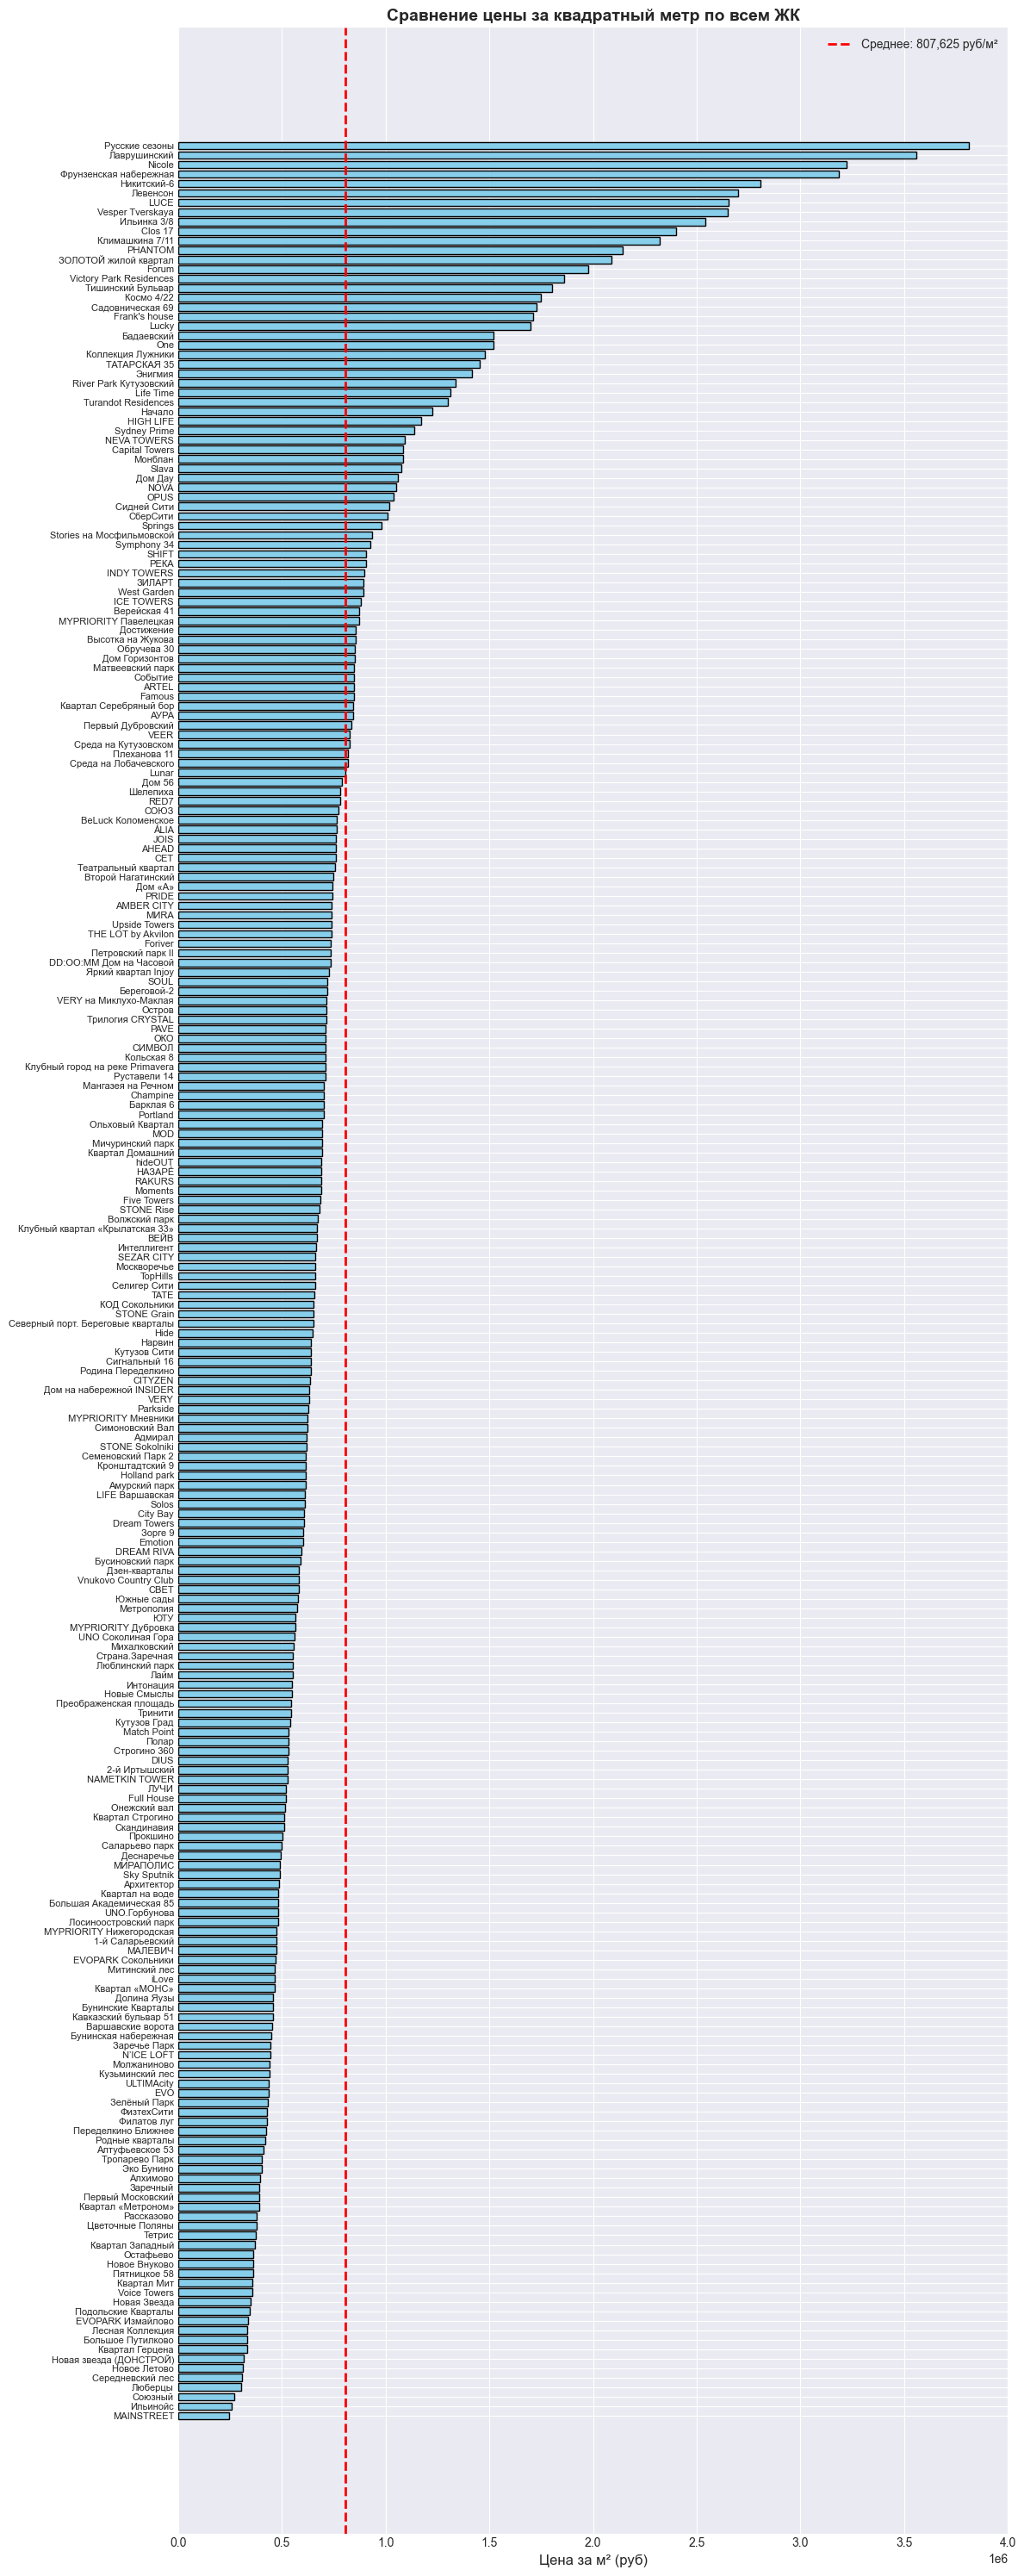

In [151]:
# Рассчитываем цену за квадратный метр
df['price_per_sqm_min'] = df['price_min'] / df['area_min'] * 1_000_000  # переводим в рубли за м²

print("=" * 70)
print("СТАТИСТИКА ПО ЦЕНЕ ЗА КВАДРАТНЫЙ МЕТР")
print("=" * 70)
print(f"Средняя цена за м²: {df['price_per_sqm_min'].mean():,.0f} руб")
print(f"Медианная цена за м²: {df['price_per_sqm_min'].median():,.0f} руб")
print(f"Мин/Макс цена за м²: {df['price_per_sqm_min'].min():,.0f} / {df['price_per_sqm_min'].max():,.0f} руб")

# ТОП-5 по лучшему соотношению цена/качество
print("\n" + "=" * 70)
print("ТОП-5 ЖК С САМОЙ НИЗКОЙ ЦЕНОЙ ЗА М²")
print("=" * 70)
top_value = df.nsmallest(5, 'price_per_sqm_min')[['title', 'price_per_sqm_min', 'price_min', 'area_min', 'metro_station']]
top_value['price_per_sqm_min'] = top_value['price_per_sqm_min'].apply(lambda x: f"{x:,.0f} руб/м²")
display(top_value)

# Визуализация цены за м²
plt.figure(figsize=(12, 30))
df_sorted = df.sort_values('price_per_sqm_min')
plt.barh(range(len(df_sorted)), df_sorted['price_per_sqm_min'], color='skyblue', edgecolor='black')
plt.yticks(range(len(df_sorted)), df_sorted['title'], fontsize=8)
plt.xlabel('Цена за м² (руб)', fontsize=12)
plt.title('Сравнение цены за квадратный метр по всем ЖК', fontsize=14, fontweight='bold')
plt.axvline(df['price_per_sqm_min'].mean(), color='red', linestyle='--', 
            label=f"Среднее: {df['price_per_sqm_min'].mean():,.0f} руб/м²", linewidth=2)
plt.legend()
plt.tight_layout()
plt.show()

In [152]:
# Сохраняем обработанные данные в CSV
df.to_csv('yandex_realty_processed.csv', index=False, encoding='utf-8')
print("✓ Данные сохранены в файл 'yandex_realty_processed.csv'")

# Краткая сводка по всему датасету
print("\n" + "=" * 70)
print("ФИНАЛЬНАЯ СВОДКА")
print("=" * 70)
print(f"Всего проанализировано ЖК: {len(df)}")
print(f"Средняя цена входа: {df['price_min'].mean():.2f} млн руб")
print(f"Средняя площадь минимальной квартиры: {df['area_min'].mean():.2f} м²")
print(f"Среднее время до метро: {df['metro_time_min'].mean():.1f} мин")
print(f"Средняя цена за м²: {df['price_per_sqm_min'].mean():,.0f} руб")
print("=" * 70)

✓ Данные сохранены в файл 'yandex_realty_processed.csv'

ФИНАЛЬНАЯ СВОДКА
Всего проанализировано ЖК: 240
Средняя цена входа: 37.69 млн руб
Средняя площадь минимальной квартиры: 38.74 м²
Среднее время до метро: 12.8 мин
Средняя цена за м²: 807,625 руб
